# Cópulas y series de tiempo: modelando dependencoa
### Actividad guiada

En clase vimos: **las marginales no determinan la conjunta**.

Dos mundos con las mismas marginales pueden tener asociaciones opuestas (recuerden la tabla de $Y=X$ frente a la independiente).

También acordamos que la independencia es una **hipótesis**, es una decisión de modelado, nunca una descripción del mundo, y que preferimos hablar de "independencia" o "no-independencia" sin postular ningún mecanismo más allá

En esta activdad veremos dos herramientas que describen mejor las dependencias: las **cópulas** (en el espacio) y la **autocorrelación** de una serie de tiempo (en el tiempo).

No espero que salgan siendo expertos en esto, sino que más bien para quedarnos con *qué hacen* y *qué resuelven*.

**Una nota de lenguaje**, fiel a lo que insistí en clase: cuando aquí digamos "asociación" o "estructura de dependencia" nos referimos a una propiedad **puramente distribucional** (cómo se mueven juntas dos variables, o una variable consigo misma en el tiempo), sin afirmar ningún mecanismo que las conecte. Una cópula es, precisamente, la descripción de esa asociación despojada de todo mecanismo. Que quede claro: describir no es explicar.

**El hilo que une los tres escenarios:** un resumen de "una variable a la vez" (la marginal; o la distribución en un instante) puede ser idéntico entre mundos con asociación radicalmente distinta. La asociación vive en **otro objeto**.

**Cómo trabajar.** Ejecuten las celdas en orden. Hay pequeños `TODO` de una o dos líneas y varios *Punto de reflexión* para escribir a mano. El código pesado ya está puesto; lo suyo es interpretar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, rankdata

rng = np.random.default_rng(1)   # semilla fija: todos ven los mismos numeritos

# Paleta del curso (la misma de las slides)
C_IND  = "#283747"   # slate -> independiente
C_POS  = "#169685"   # teal  -> asociacion positiva
C_NEG  = "#b03a2e"   # rojo  -> asociacion negativa
C_GOLD = "#bc8e3a"   # oro   -> intermedio

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 11})

def exp1_quantile(u):
    # Cuantil inversa de una Exponencial(1): convierte U~Unif(0,1) en X~Exp(1).
    return -np.log(1.0 - u)

## Antes de empezar: ¿qué es una cópula? (mini-intro)

En clase quedó una idea suelta: las marginales no determinan la conjunta. Sabemos describir cada variable por su lado y sabemos preguntar si dos variables son independientes o no, pero nos falta un objeto que aísle *cómo se acompañan*, separado de la forma de cada una. Ese objeto es la **cópula**, y a continuación se define con precisión y se muestra cómo se opera.

**El motor: la transformada integral de probabilidad.** Sea $X$ continua con CDF $F_X$. Dos hechos, uno inverso del otro:

- Si aplico su propia CDF, la estandarizo a uniforme: $U = F_X(X) \sim \mathrm{Uniforme}(0,1)$.
- Si parto de una uniforme y aplico la cuantil (la CDF inversa), le impongo la marginal que quiera: $X = F_X^{-1}(U)$ tiene CDF $F_X$ (esto es el muestreo por inversión).

La primera dirección **le quita** a una variable su forma marginal; la segunda **se la pone**. Toda la "forma" de $X$ vive en $F_X$; una vez estandarizada, lo único que puede sobrevivir de un par de variables es *cómo se acompañan sus uniformes*.

**Definición.** Una **cópula** es una función $C:[0,1]^2 \to [0,1]$ que es, ella misma, la CDF conjunta de un par $(U,V)$ con marginales $\mathrm{Uniforme}(0,1)$. De forma equivalente, $C$ cumple tres condiciones:

1. $C(u,0) = C(0,v) = 0$ (se anula en los bordes inferiores).
2. $C(u,1) = u$ y $C(1,v) = v$ (sus marginales son uniformes).
3. Para todo $u_1 \le u_2$, $v_1 \le v_2$: $\;C(u_2,v_2) - C(u_2,v_1) - C(u_1,v_2) + C(u_1,v_1) \ge 0$ (la probabilidad de cualquier rectángulo es no negativa).

**Teorema de Sklar (1959).** Sea $H$ la CDF conjunta de $(X,Y)$ con marginales $F_X, F_Y$. Entonces existe una cópula $C$ tal que

$$H(x,y) = C\big(F_X(x),\, F_Y(y)\big) \qquad \text{para todo } (x,y),$$

y si las marginales son continuas, $C$ es **única**. Recíprocamente, si tomo cualesquiera marginales $F_X, F_Y$ y cualquier cópula $C$, la $H$ definida por esa fórmula es una conjunta legítima. La cópula se **recupera** despejando con las cuantiles:

$$C(u,v) = H\big(F_X^{-1}(u),\, F_Y^{-1}(v)\big).$$

Esta última fórmula es, literalmente, "toma la conjunta y quítale las marginales". Lo que queda, definido sobre el cuadrado $[0,1]^2$, es la asociación pura.

**En densidades (aquí se ve qué hace).** Derivando la identidad de Sklar, con $c(u,v) = \dfrac{\partial^2 C(u,v)}{\partial u\, \partial v}$ la densidad de la cópula:

$$f(x,y) = \underbrace{f_X(x)\, f_Y(y)}_{\text{caso independiente}} \;\cdot\; \underbrace{c\big(F_X(x),\, F_Y(y)\big)}_{\text{correccion por asociacion}}.$$

Dicho de otro modo, la conjunta es el producto de las marginales (la parte independiente de la S3) multiplicado por la densidad de la cópula, que actúa como el **factor de corrección** que introduce la asociación. La independencia corresponde exactamente a $c \equiv 1$: sin corrección, la conjunta factoriza.

**Tres cópulas de referencia y las cotas de Fréchet–Hoeffding.** Toda cópula queda atrapada entre dos extremos:

$$W(u,v) = \max(u+v-1,\, 0) \;\le\; C(u,v) \;\le\; \min(u,v) = M(u,v),$$

y en medio vive la independencia $\Pi(u,v) = uv$. La cota superior $M$ es el acoplamiento comonótono (asociación positiva perfecta), la inferior $W$ es el contramonótono (negativa perfecta), y $\Pi$ es apenas un punto entre ambas. Estos son, exactamente, los tres acoplamientos del Escenario 1.

**Cómo se opera, en resumen.**

- **Construir** una conjunta: elige marginales $F_X, F_Y$ y una cópula $C$; define $H(x,y) = C(F_X(x), F_Y(y))$.
- **Simular** un par: sortea $(U,V)$ con distribución $C$, y devuelve $X = F_X^{-1}(U)$, $Y = F_Y^{-1}(V)$.
- **Extraer** la cópula de datos: aplica la transformada integral a cada coordenada (en la práctica, con rangos), y observa lo que queda en $[0,1]^2$.

Con esto, los dos pasos del Escenario 1 se leen sin misterio: "elegir cómo acoplo $U$ y $V$" es fijar la cópula $C$, y "empujar por la cuantil inversa" es aplicar $F^{-1}$ para imponer la marginal $\mathrm{Exp}(1)$. Cambiar el primer paso dejando fijo el segundo es cambiar la asociación sin mover las marginales.


## Escenario 1

**Receta de construcción (Sklar en reversa).** Para fabricar un par $(X,Y)$ con las marginales que yo quiera y la asociación que yo quiera bastan dos pasos:

1. **Elegir cómo acoplo** dos uniformes $U,V \in (0,1)$.
2. **Empujar** cada uniforme por la cuantil inversa de la marginal deseada.

La **cópula es exactamente el paso 1**: el acoplamiento de las uniformes. La marginal es el paso 2. Vamos a fijar la **misma** marginal para las dos variables, una $\mathrm{Exp}(1)$, y a cambiar **solo el acoplamiento**. Tres acoplamientos triviales:

- **Independiente:** $V$ se sortea aparte de $U$.
- **Comonótono:** $V=U$ (asociación positiva perfecta).
- **Contramonótono:** $V=1-U$ (asociación negativa perfecta).

In [2]:
n = 4000
U = rng.random(n)

# Tres acoplamientos de las uniformes  ->  ESTO es la copula
V_ind = rng.random(n)     # independiente
V_com = U                 # comonotono      (V = U)
V_con = 1.0 - U           # contramonotono  (V = 1 - U)

# Paso 2, identico para los tres: empujar por la cuantil de una Exp(1)
X     = exp1_quantile(U)
Y_ind = exp1_quantile(V_ind)
Y_com = exp1_quantile(V_com)
Y_con = exp1_quantile(V_con)

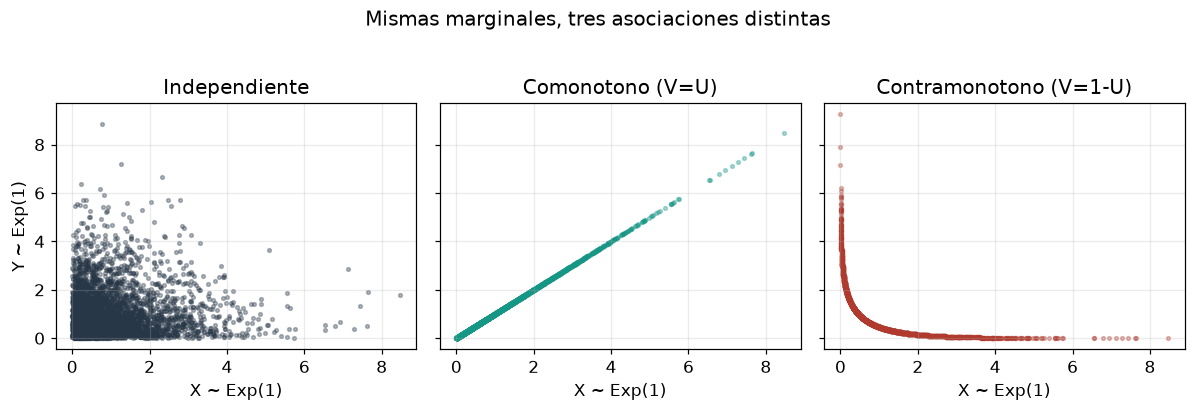

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True, sharey=True)
for a, Yv, col, tit in [(ax[0], Y_ind, C_IND, "Independiente"),
                        (ax[1], Y_com, C_POS, "Comonotono (V=U)"),
                        (ax[2], Y_con, C_NEG, "Contramonotono (V=1-U)")]:
    a.scatter(X, Yv, s=6, alpha=0.35, color=col)
    a.set_title(tit); a.set_xlabel("X ~ Exp(1)")
ax[0].set_ylabel("Y ~ Exp(1)")
fig.suptitle("Mismas marginales, tres asociaciones distintas", y=1.03)
plt.tight_layout(); plt.show()

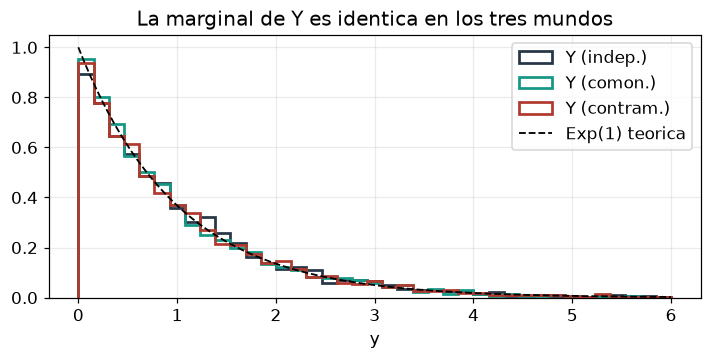

In [4]:
# Chequeo: la marginal de Y es la MISMA en los tres mundos
fig, ax = plt.subplots(figsize=(6.6, 3.4))
bins = np.linspace(0, 6, 40)
for Yv, col, lab in [(Y_ind, C_IND, "Y (indep.)"),
                     (Y_com, C_POS, "Y (comon.)"),
                     (Y_con, C_NEG, "Y (contram.)")]:
    ax.hist(Yv, bins=bins, histtype="step", density=True, color=col, label=lab, lw=1.8)
xx = np.linspace(0, 6, 200)
ax.plot(xx, np.exp(-xx), "k--", lw=1.2, label="Exp(1) teorica")
ax.set_title("La marginal de Y es identica en los tres mundos")
ax.set_xlabel("y"); ax.legend(); plt.tight_layout(); plt.show()

**Punto de reflexión 1.** Los tres paneles comparten marginales idénticas (lo acaban de ver en el histograma). ¿Qué es, entonces, lo único que cambia entre ellos? Escríbanlo con sus palabras.

RESPUESTA: La diferencia entre los 3 casos es la forma en que los datos están distribuidos. Mientras que en la independiente se agrupan en la esquina inferior izquierda, en la comonótona forman una linea recta, y en la contramonótona se forma una estructura logarítmica.

**Punto a mano (sin código).** La "cantidad de acoplamiento" tiene un rango. Evalúen $P(U \le 0.5,\ V \le 0.5)$ en los tres casos:

- Comonótono: $\min(0.5,\ 0.5) = 0.5{\quad}$
- Independiente: $0.5 \cdot 0.5 = 0.25{\quad}$
- Contramonótono: $\max(0.5 + 0.5 - 1,\ 0) = 0{\quad}$

Esos tres valores ($0.5,\ 0.25,\ 0$) son las **cotas de Fréchet–Hoeffding**: el acoplamiento comonótono y el contramonótono son los **dos extremos posibles**, y la independencia $C(u,v)=uv$ es apenas **el punto de en medio**. La independencia no es "la ausencia de asociación", sino que más bien es un punto particular dentro de todo un rango de acoplamientos.

In [16]:
# TO-DO (1): estima por Monte Carlo la probabilidad del evento de cola CONJUNTO
#           P(X > 2  y  Y > 2)  en cada acoplamiento.
#   Pista: para dos vectores booleanos, (X > 2) & (Yv > 2) es True donde AMBOS pasan;
#          np.mean(...) sobre un vector booleano estima la probabilidad.
p_ind = np.mean(((X > 2) & (Y_ind > 2)))
p_com = np.mean(((X > 2) & (Y_com > 2)))
p_con = np.mean(((X > 2) & (Y_con > 2)))

print(f"P(X>2, Y>2) | independiente : {p_ind:.4f}")
print(f"P(X>2, Y>2) | comonotono     : {p_com:.4f}")
print(f"P(X>2, Y>2) | contramonotono : {p_con:.4f}")
print(f"\nAncla teorica:  P(X>2) = e^-2 = {np.exp(-2):.4f}")
print(f"Si fueran independientes:  (e^-2)^2 = {np.exp(-4):.4f}")

P(X>2, Y>2) | independiente : 0.0200
P(X>2, Y>2) | comonotono     : 0.1373
P(X>2, Y>2) | contramonotono : 0.0000

Ancla teorica:  P(X>2) = e^-2 = 0.1353
Si fueran independientes:  (e^-2)^2 = 0.0183


**Punto de reflexión 2.** Comparen sus tres números con las dos anclas teóricas. El comonótono debería rondar $e^{-2}\approx 0.135$ (cuando $Y=X$, "ambos grandes" es lo mismo que "$X$ grande"); el independiente $\approx 0.018$; y el contramonótono **exactamente $0$** (si $X$ es grande, $Y=-\ln U$ es chico, no pueden ser grandes a la vez). Una misma pregunta de riesgo "¿qué tan seguido pasan las dos cosas a la vez?" tiene **tres respuestas que difieren por un factor enorme**, con marginales idénticas. Esto es lo que una cópula resuelve y las marginales no pueden ni tocar.

### La transformada integral de probabilidad: aislar la asociación

Hasta aquí **construimos** la conjunta. Ahora al revés: dado un par $(X,Y)$, ¿cómo aíslo su asociación y le quito la forma marginal? Con la **transformada integral de probabilidad** (PIT): a cada coordenada le aplico su propia CDF (aquí, vía rangos empíricos) y la vuelvo Uniforme $(0,1)$. Lo que queda, la conjunta de $(U,V)$, **es la cópula**: la asociación desnuda.

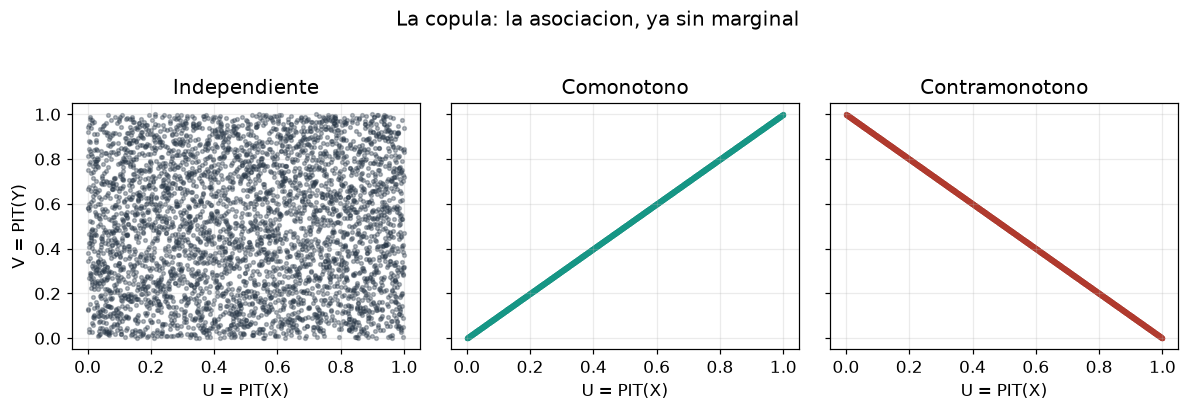

In [17]:
def pit(x):
    # Transformada integral de probabilidad empirica: manda x a (0,1) por su rango.
    return rankdata(x) / (len(x) + 1)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True, sharey=True)
for a, Yv, col, tit in [(ax[0], Y_ind, C_IND, "Independiente"),
                        (ax[1], Y_com, C_POS, "Comonotono"),
                        (ax[2], Y_con, C_NEG, "Contramonotono")]:
    a.scatter(pit(X), pit(Yv), s=6, alpha=0.35, color=col)
    a.set_title(tit); a.set_xlabel("U = PIT(X)")
ax[0].set_ylabel("V = PIT(Y)")
fig.suptitle("La copula: la asociacion, ya sin marginal", y=1.03)
plt.tight_layout(); plt.show()

**Punto de reflexión 3.** En el plano $(U,V)$ los ejes son Uniforme $(0,1)$ **siempre** (le quitamos a cada variable su forma). Lo único que sobrevive es el patrón: nube sin estructura (independiente), diagonal (comonótono), anti-diagonal (contramonótono). **Guarden esta imagen:** la van a reencontrar, idéntica, en el Escenario 3, pero con el tiempo en el eje.

> **Punto de rigor.** Una cópula te compra una cosa y no te vende otra. Te **compra**: elegir la asociación entre variables sin tocar sus marginales, y separar por completo "cómo se ve cada variable" de "cómo se mueven juntas". No te **vende**: ningún mecanismo. La cópula describe la estructura de asociación en sentido distribucional; no dice *por qué* se relacionan ni cuál causa a cuál. Es la contraparte exacta de nuestra postura de la S3: aquí describimos la (no-)independencia con más resolución, pero seguimos sin postular un mecanismo.

---

## Escenario 2:

En el Escenario 1 los acoplamientos eran extremos ($0$, $+1$, $-1$ de asociación). En la práctica uno quiere un **dial continuo**. La **cópula gaussiana** ofrece uno: un solo parámetro $\rho \in (-1,1)$ que gradúa la asociación, dejando las marginales intactas.

**Receta.** Sorteo un par normal estándar $(Z_1, Z_2)$ con correlación $\rho$; los vuelvo uniformes con $\Phi$; y empujo cada uniforme por la cuantil de la marginal deseada (otra vez $\mathrm{Exp}(1)$). Cambio $\rho$ y observo. Fíjense: **las marginales no se enteran de $\rho$**.

Este es, con nombres y fechas, el modelo que Li (2000) llevó a Wall Street y que las slides mencionaron para 2008: una cópula gaussiana resumiendo toda la dependencia entre impagos en **un** número $\rho$.

In [18]:
def par_gaussiano(rho, n, rng):
    # Par (X, Y) con marginales Exp(1) y copula gaussiana de parametro rho.
    Z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=n)
    U = norm.cdf(Z[:, 0])
    V = norm.cdf(Z[:, 1])
    return exp1_quantile(U), exp1_quantile(V)

n2   = 20000
rhos = [0.0, 0.5, 0.9]
pares = {r: par_gaussiano(r, n2, rng) for r in rhos}

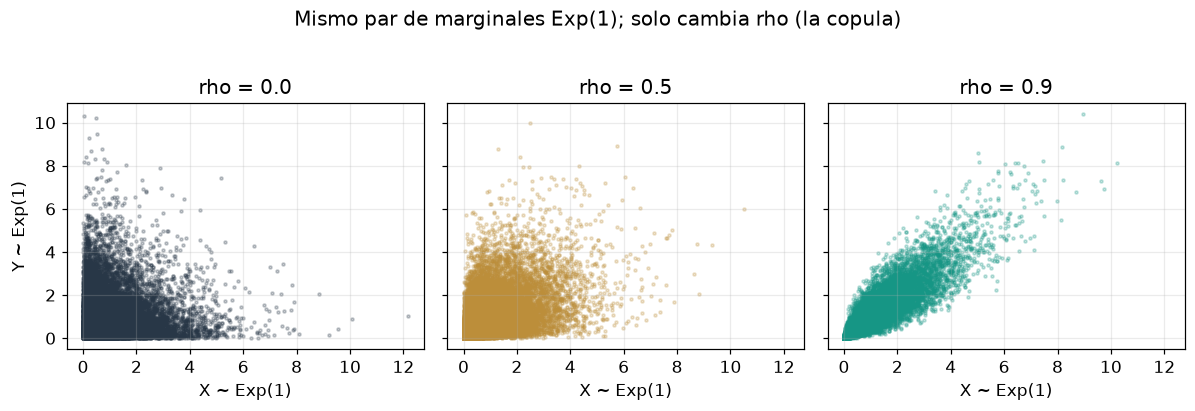

rho=0.0:  media(X)=0.988  media(Y)=0.992   (Exp(1) tiene media 1)
rho=0.5:  media(X)=0.998  media(Y)=1.003   (Exp(1) tiene media 1)
rho=0.9:  media(X)=1.001  media(Y)=1.006   (Exp(1) tiene media 1)


In [19]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True, sharey=True)
for a, r, col in zip(ax, rhos, [C_IND, C_GOLD, C_POS]):
    Xr, Yr = pares[r]
    a.scatter(Xr, Yr, s=4, alpha=0.25, color=col)
    a.set_title(f"rho = {r}"); a.set_xlabel("X ~ Exp(1)")
ax[0].set_ylabel("Y ~ Exp(1)")
fig.suptitle("Mismo par de marginales Exp(1); solo cambia rho (la copula)", y=1.03)
plt.tight_layout(); plt.show()

# La marginal de X sigue siendo Exp(1) (media ~ 1) para todo rho
for r in rhos:
    Xr, Yr = pares[r]
    print(f"rho={r}:  media(X)={Xr.mean():.3f}  media(Y)={Yr.mean():.3f}   (Exp(1) tiene media 1)")

Ahora medimos el **riesgo de cola conjunto**: la probabilidad de que las dos variables superen a la vez un umbral alto. Elegimos el umbral en el percentil 90 de la $\mathrm{Exp}(1)$, es decir $q=-\ln(0.10)$, de modo que $P(X>q)=0.10$ **exacto** para cualquier $\rho$. Bajo independencia, el evento conjunto tendría probabilidad $0.10^2 = 0.01$.

In [33]:
q = -np.log(0.10)          # percentil 90 de Exp(1):  P(X > q) = 0.10  exacto
print(f"Umbral q = {q:.3f},  con  P(X>q) = 0.10  para cualquier rho\n")

# TO-DO (2): estima  P(X > q  y  Y > q)  para cada rho.
for r in rhos:
    Xr, Yr = pares[r]
    p_conjunta = np.mean(((Xr > q) & (Yr > q)))
    factor = p_conjunta / 0.01    # 0.01 = 0.10^2 es el valor bajo independencia
    print(f"rho={r}:  P(ambos > q) = {p_conjunta:.4f}   ->  {factor:.1f}x el caso independiente")

Umbral q = 2.303,  con  P(X>q) = 0.10  para cualquier rho

rho=0.0:  P(ambos > q) = 0.0097   ->  1.0x el caso independiente
rho=0.5:  P(ambos > q) = 0.0337   ->  3.4x el caso independiente
rho=0.9:  P(ambos > q) = 0.0670   ->  6.7x el caso independiente


**Punto de reflexión 4.** Con $\rho=0$ recuperan $\approx 0.01$ (la independencia). Al subir $\rho$, la probabilidad de que las dos cosas fallen **a la vez** se multiplica varias veces, y las marginales ni se movieron (la media de $X$ sigue en $1$). Cambien mentalmente "$X$, $Y$" por "impago de la hipoteca A, impago de la hipoteca B": calibrar $\rho$ demasiado bajo hace ver los desastres conjuntos como rarísimos.

> **Punto de rigor (cierre 2008).** Las slides lo dijeron así: el modelo "tenía bien las marginales y catastróficamente mal la conjunta". Aquí lo tocaron con las manos: fijar bien cada marginal **no dice nada** sobre la cola conjunta; esa vive en la cópula, en $\rho$. Un matiz honesto, para no repetir el error a la inversa: la cópula gaussiana tiene además una patología propia, su **dependencia de cola tiende a cero** (los extremos conjuntos se "desacoplan" aunque $\rho$ sea alto). Modelar la asociación es tan delicado como modelar cada marginal; **elegir la familia de cópula es otra firma**.

**Para pensar (opcional).** Sin correr nada: si el umbral fuera aún más extremo (percentil 99 en vez de 90), ¿esperarían que la brecha entre $\rho=0$ y $\rho=0.9$ crezca o se encoja? Anoten su predicción; si quieren, cambien el `0.10` por `0.01` arriba y verifiquen.



## Escenario 3 Series de tiempo: la no-independencia en el tiempo

Las slides listaron la "dinámica temporal (la demanda de hoy predice la de mañana)" como una fuente de no-independencia. Aquí la vemos en el objeto más simple posible, un **AR(1)**:

$$x_t = \phi\, x_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,1)\ \text{independientes.}$$

$\phi$ es el **dial de asociación temporal**. Con $\phi=0$ cada $x_t$ es un sorteo independiente: es **ruido blanco**, el "i.i.d." de la S3 y la S4 en persona. Con $\phi\neq 0$, el pasado informa al presente. Tres valores triviales: $\phi=0$ (independiente), $\phi=0.8$ (memoria positiva fuerte), $\phi=-0.6$ (alternancia).

In [34]:
def ar1(phi, n, rng, sigma=1.0):
    # Simula un AR(1) ya estacionario: x_t = phi x_(t-1) + eps_t.
    x  = np.empty(n)
    g0 = sigma**2 / (1 - phi**2)          # varianza estacionaria
    x[0] = rng.normal(0, np.sqrt(g0))     # arranca en regimen estacionario
    eps  = rng.normal(0, sigma, size=n)
    for t in range(1, n):
        x[t] = phi * x[t-1] + eps[t]
    return x

n3   = 300
phis = [0.0, 0.8, -0.6]
series = {p: ar1(p, n3, rng) for p in phis}

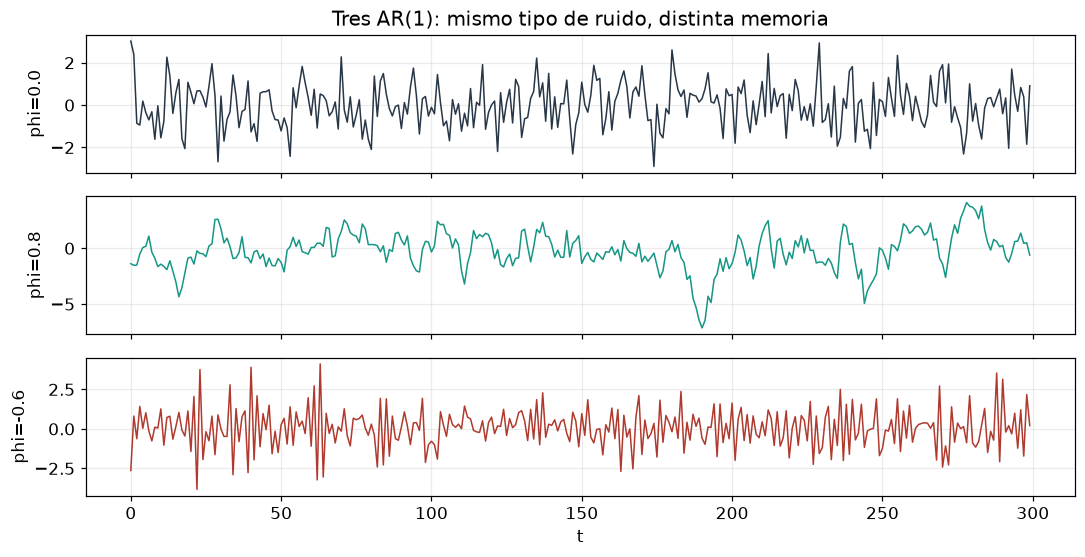

In [35]:
fig, ax = plt.subplots(3, 1, figsize=(10, 5.2), sharex=True)
for a, p, col in zip(ax, phis, [C_IND, C_POS, C_NEG]):
    a.plot(series[p], color=col, lw=1.0)
    a.set_ylabel(f"phi={p}")
ax[0].set_title("Tres AR(1): mismo tipo de ruido, distinta memoria")
ax[-1].set_xlabel("t"); plt.tight_layout(); plt.show()

**Punto de reflexión 5.** El de arriba ($\phi=0$) no tiene memoria: brinca sin patrón. El de en medio ($\phi=0.8$) hace olas lentas: cada punto se parece al anterior. El de abajo ($\phi=-0.6$) zigzaguea: cada punto tiende al signo opuesto del anterior. Ahora grafiquemos $x_t$ contra su pasado $x_{t-1}$.

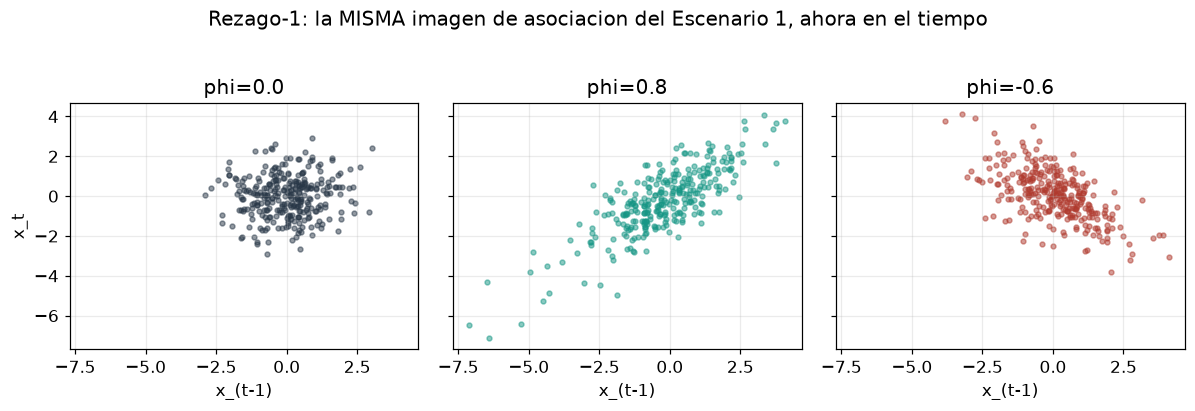

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True, sharey=True)
for a, p, col in zip(ax, phis, [C_IND, C_POS, C_NEG]):
    x = series[p]
    a.scatter(x[:-1], x[1:], s=10, alpha=0.5, color=col)
    a.set_title(f"phi={p}"); a.set_xlabel("x_(t-1)")
ax[0].set_ylabel("x_t")
fig.suptitle("Rezago-1: la MISMA imagen de asociacion del Escenario 1, ahora en el tiempo", y=1.03)
plt.tight_layout(); plt.show()

**Punto de reflexión 6.** Comparen estos tres paneles con los de la cópula (Escenario 1, plano $(U,V)$): nube sin estructura, diagonal, anti-diagonal. La asociación temporal de un AR(1) es, **visualmente, la misma clase de objeto** que una cópula: describe cómo se acompaña $x_t$ con su pasado.

In [37]:
# TO-DO (3): calcula la autocorrelacion de rezago 1, corr(x_t, x_(t-1)), para cada serie.
#   Pista: np.corrcoef(a, b)[0, 1] da la correlacion entre dos vectores.
#          Usa x[:-1] (pasado) y x[1:] (presente).
for p in phis:
    x  = series[p]
    r1 = np.corrcoef(x[1:], x[:-1])[0, 1]
    print(f"phi={p:>4}:  corr(x_t, x_(t-1)) muestral = {r1:+.3f}   |  teorico phi^1 = {p:+.3f}")

phi= 0.0:  corr(x_t, x_(t-1)) muestral = +0.074   |  teorico phi^1 = +0.000
phi= 0.8:  corr(x_t, x_(t-1)) muestral = +0.802   |  teorico phi^1 = +0.800
phi=-0.6:  corr(x_t, x_(t-1)) muestral = -0.612   |  teorico phi^1 = -0.600


**A mano.** Para un AR(1) la autocorrelación a rezago $k$ vale **exactamente $\phi^k$**. Verifíquenlo: para $\phi=0.8$, rezago 1 debe dar $0.8$; rezago 2, $0.64$; rezago 3, $\approx 0.512$. Los suyos son muestrales, así que rondarán esos valores con algo de ruido. La siguiente celda dibuja la ACF completa contra $\phi^k$.

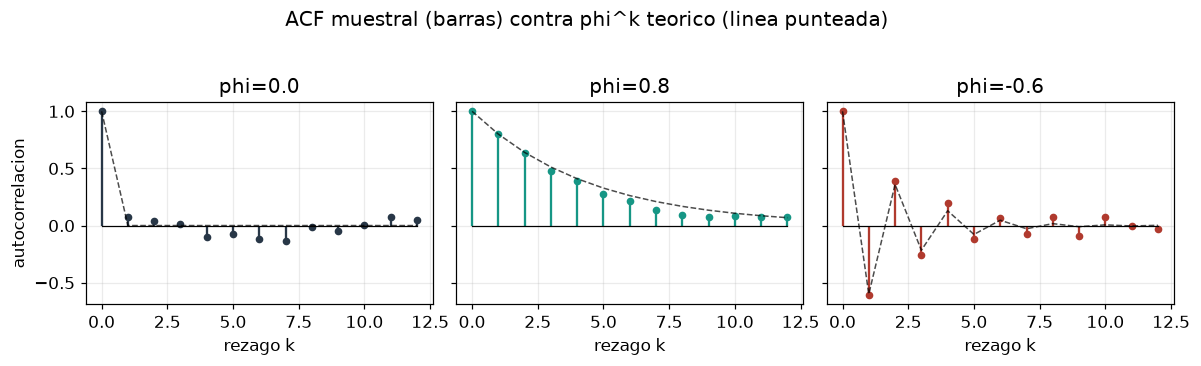

In [38]:
def acf(x, K):
    # Autocorrelacion muestral hasta rezago K.
    x  = x - x.mean()
    g0 = np.mean(x * x)
    return np.array([1.0] + [np.mean(x[k:] * x[:-k]) / g0 for k in range(1, K + 1)])

K = 12
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for a, p, col in zip(ax, phis, [C_IND, C_POS, C_NEG]):
    r = acf(series[p], K)
    ml, sl, bl = a.stem(range(K + 1), r)
    plt.setp(sl, color=col); plt.setp(ml, color=col, markersize=4)
    plt.setp(bl, color="k", lw=0.8)
    a.plot(range(K + 1), [p**k for k in range(K + 1)], "k--", lw=1, alpha=0.7)
    a.set_title(f"phi={p}"); a.set_xlabel("rezago k")
ax[0].set_ylabel("autocorrelacion")
fig.suptitle("ACF muestral (barras) contra phi^k teorico (linea punteada)", y=1.03)
plt.tight_layout(); plt.show()

### Barajar: conservar la marginal, borrar la asociación

In [39]:
# TO-DO (4): "baraja" la serie de phi=0.8 (permuta el orden de sus valores) y vuelve a medir
#           la autocorrelacion de rezago 1. Los numeros son los mismos, solo cambia el orden.
x          = series[0.8]
x_barajado = rng.permutation(x)

r1_original = np.corrcoef(x[:-1], x[1:])[0, 1]
r1_barajado = np.corrcoef(x_barajado[:-1], x_barajado[1:])[0, 1]

print(f"corr rezago-1  original : {r1_original:+.3f}")
print(f"corr rezago-1  barajado : {r1_barajado:+.3f}   (colapsa a ~0)")
print(f"\nMedia y desv. est.  original : {x.mean():+.3f}, {x.std():.3f}")
print(f"Media y desv. est.  barajado : {x_barajado.mean():+.3f}, {x_barajado.std():.3f}   (identicas)")

corr rezago-1  original : +0.802
corr rezago-1  barajado : +0.003   (colapsa a ~0)

Media y desv. est.  original : -0.241, 1.669
Media y desv. est.  barajado : -0.241, 1.669   (identicas)


**Punto de reflexión 7.** Barajar **conserva la marginal** (los mismos números, media y desviación idénticas) y **destruye la asociación temporal** (la autocorrelación se va a cero). Es el reflejo exacto de la PIT del Escenario 1: allá conservábamos la asociación y estandarizábamos la marginal; aquí conservamos la marginal y borramos la asociación. **Marginal y asociación son perillas independientes**, en el espacio y en el tiempo.

### El $\sqrt{n}$ que miente (puente a la S4)

Una consecuencia práctica. Las slides advirtieron que si los datos están correlacionados, el error de la media baja mucho más lento que $1/\sqrt{n}$ y los intervalos "mienten hacia el lado peligroso". Midámoslo: simulamos muchas series AR(1), calculamos la media de cada una, y comparamos la **varianza real** de esas medias contra la fórmula ingenua $\gamma_0/n$ que asume independencia.

In [40]:
def var_media_montecarlo(phi, n, reps, rng):
    medias = np.array([ar1(phi, n, rng).mean() for _ in range(reps)])
    return medias.var()

n_serie, reps = 200, 2000
print(f"Serie de largo n = {n_serie};  {reps} repeticiones por phi\n")
for p in [0.0, 0.8, -0.6]:
    g0           = 1.0 / (1 - p**2)                       # varianza estacionaria
    var_real     = var_media_montecarlo(p, n_serie, reps, rng)
    var_ingenua  = g0 / n_serie                           # asumiendo i.i.d.
    var_correcta = (g0 / n_serie) * (1 + p) / (1 - p)     # correccion por autocorrelacion
    n_efectivo   = n_serie * (1 - p) / (1 + p)
    print(f"phi={p:>4}:  Var(media) real={var_real:.5f} | ingenua (g0/n)={var_ingenua:.5f} "
          f"| corregida={var_correcta:.5f} | n_efectivo~{n_efectivo:.0f} de {n_serie}")

Serie de largo n = 200;  2000 repeticiones por phi

phi= 0.0:  Var(media) real=0.00527 | ingenua (g0/n)=0.00500 | corregida=0.00500 | n_efectivo~200 de 200
phi= 0.8:  Var(media) real=0.12249 | ingenua (g0/n)=0.01389 | corregida=0.12500 | n_efectivo~22 de 200
phi=-0.6:  Var(media) real=0.00196 | ingenua (g0/n)=0.00781 | corregida=0.00195 | n_efectivo~800 de 200


**Punto de reflexión 8.** Lean el renglón de $\phi=0.8$: la varianza real de la media es cerca de **9 veces** la que reportaría alguien asumiendo independencia. Dicho de otro modo, $n=200$ observaciones correlacionadas valen, para estimar la media, como $n_{\text{efectivo}} \approx 22$ independientes. Reportar $\sigma/\sqrt{200}$ sería un exceso de confianza brutal, justo el "lado peligroso" de las slides.

Un matiz que rara vez se enseña: **no toda dependencia infla el error**. Miren $\phi=-0.6$: la alternancia hace que la varianza de la media sea **menor** que la ingenua, y $n_{\text{efectivo}} > n$. La autocorrelación positiva castiga; la negativa, en promedio, ayuda. "Dependencia" no es sinónimo de "peor"; hay que mirar su forma (otro eco del $Y=X^2$: la etiqueta gruesa engaña, la forma manda).

> **Punto de rigor de cierre.** El $1/\sqrt{n}$ que sostiene casi toda la S4 firma independencia. Cuando los datos tienen memoria, ese $\sqrt{n}$ hay que corregirlo por el $n_{\text{efectivo}}$, y la corrección puede ser de **un orden de magnitud**.

---

## Resumen

Los tres escenarios contaron la misma historia con dos vestuarios. En las **cópulas**, dos variables con marginales idénticas podían tener asociaciones opuestas; la cópula era la asociación, aislada por la PIT. En el **AR(1)**, una serie con marginal fija podía tener memoria o no; la autocorrelación era esa memoria, y barajar la borraba sin tocar la marginal.

La moraleja, la misma de la S3 subida de resolución: **modelar bien cada variable por separado (las marginales) no dice nada sobre cómo se mueven juntas (la asociación)**. La asociación es un objeto aparte, con su propia perilla: $\rho$ o la familia de cópula en el espacio, $\phi$ y la ACF en el tiempo.

Y fieles a la postura de clase: en ningún momento postulamos un mecanismo. Describimos **estructura de asociación en sentido distribucional**. Cuál variable causa a cuál, o si hay una causa común detrás, sigue siendo una pregunta aparte (la de Reichenbach de la S3, la de la S24). Describir con más finura la (no-)independencia no nos acercó ni un milímetro a **explicarla**.

| | Cópulas (espacio) | Serie de tiempo (tiempo) |
|---|---|---|
| Qué se fija | la(s) marginal(es) | la distribución de un instante |
| Dónde vive la asociación | la cópula $C(u,v)$ | la autocorrelación $\phi^k$ |
| La perilla | $\rho$ / familia de cópula | $\phi$ |
| Operación que aísla la asociación | PIT (estandariza la marginal) | ver $x_t$ vs $x_{t-1}$ |
| Operación que la destruye | fijar cópula independiente $uv$ | barajar la serie |
| El caso "independiente" | $C(u,v)=uv$ | $\phi=0$ (ruido blanco) |

**Preguntas de cierre** (para escribir a mano):

1. En una sola frase: ¿qué hace una cópula que las marginales no pueden hacer? Logra determinar la estructura de cómo se conectan las variables X y Y, y junto a las marginales contruye su distribución de probabilidad conjunta. Algo que no puede hacer la marginal, pues justamente elimina la información de cómo se relacionan las variables entre sí.

2. ¿Por qué "las palabras van juntas en el spam" (S3, Naive Bayes) y "la demanda de hoy predice la de mañana" son, en el fondo, el mismo fenómeno visto en el Escenario 1 y en el 3? En ambos casos existe dependencia entre variable, por lo que en los dos escenarios se puede ver cómo lo observado con anterioridad aporta información sobre lo que ocurre después.


3. Un colega reporta la media de una serie con intervalo $\bar{x} \pm \sigma/\sqrt{n}$ y la serie tiene $\phi=0.8$. ¿Qué le dirían, y con qué número? Dado ese intervalo, se está haciendo una suposición importante: se define independencia. Esto poeque la varianza de la media se infla aproximadamente por un factor de 9 y el error estándar por un factor de 3. 


**Para leer más** (fuera del programa, pero ahora con intuición de qué resuelven): Sklar (1959) y Nelsen, *An Introduction to Copulas*; Box & Jenkins para series de tiempo.